# Comparison experiments


In [11]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from mfld import MeanFieldLangevinDynamics
from generalized_svgd import GeneralizedSVGD
from extensible_sampling import ExtensibleSampling
from variational_inference import VariationalInference
import functions as f

import jax
from jax import random

# 1. $\mathcal{L}$ is linear.

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x)$, with $v(x) =  \frac{-\|x\|^2}{4}$


In this case, $\mathcal{L}'(Q)(x) = v(x)$ and $p(x) \propto e^{-\frac{\|x\|^2}{4}}$, so $P = \mathcal{N}(0,2 I_d)$.

KGD kernel :  IMQ   : $k(x,y) = \frac{1}{\sqrt{c + \|x-y\|^2}}$. 


<!-- F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->


In [2]:
results = {
    "MFLD": {
        "X_fin": None,
        "KGD": None
    },
    "Generalized SVGD": {
        "X_fin": None,
        "KGD_values": None
    },
    "ES": {
        "X_fin": None,
        "KGD_values": None
    },
    "VI": {
        "X_fin": None,
        "KGD_values": None
    }
}

In [12]:
#Upload results
import pickle

# Chargement depuis le fichier
with open("results.pkl", "rb") as g:
    results = pickle.load(g)

In [13]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)

In [14]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k)
d=2
#F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

# Mean Field Langevin Dynamics

In [122]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k)

T = 1000
n = 100
d = 2
eta = 0.1 # the best stepsize 

key_init = random.PRNGKey(100)
key = random.PRNGKey(200)
X0 = random.normal(key_init, (n,d)) + 5 * jnp.ones((n, d))

all_particles = MFLD.run_particles(eta, T, X0,key)
results["MFLD"]["X_fin"] = all_particles[-1]

KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))

results["MFLD"]["KGD"] = KGD_values


# Generalized SVGD

In [123]:
sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm)

T = 1000
n = 50
d = 2
eta = 2.0 # the best stepsize 

key_init = random.PRNGKey(100)
X0 = random.normal(key_init, (n,d)) + 2 * jnp.ones((n, d))

all_particles = G_SVGD.run_particles(eta, T, X0)
results["Generalized SVGD"]["X_fin"] = all_particles[-1]

KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))

results["Generalized SVGD"]["KGD"] = KGD_values


# Extansible sampling 

In [7]:
ES = ExtensibleSampling(q_0,L,k)

T = 100
d = 2

key = random.PRNGKey(200)
x0 = random.normal(key, (d,)) 
X_fin = ES.run_particles(x0,T)

results["ES"]["X_fin"] = X_fin

KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(X_fin[:it+1]))

results["ES"]["KGD"] = KGD_values


Iteration: 10
Iteration: 20
Iteration: 30
Iteration: 40
Iteration: 50
Iteration: 60
Iteration: 70
Iteration: 80
Iteration: 90


# Variational Inference

In [15]:
eta = 0.1
T = 1000
d = 2

VI = VariationalInference(q_0,L,k,d,[5],"tanh")

key = random.PRNGKey(1)
Theta = VI.run(key,eta,T)
theta_fin = Theta[-1]

W_fin = random.normal(random.PRNGKey(2), (100, d))
X_fin = VI.push_T_theta(theta_fin, W_fin)
results["VI"]["X_fin"] = X_fin

[]


In [16]:

W0 = random.normal(random.PRNGKey(2), (1000, d))
X = jnp.array([VI.push_T_theta(theta, W0) for theta in Theta])
KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(X[it]))
results["VI"]["KGD"] = KGD_values

Save data:

In [17]:
import pickle

# Sauvegarde dans un fichier binaire
with open("results.pkl", "wb") as f:
    pickle.dump(results, f)

# Comparison of the experiments

Here we plot the final particles position obtained for each of the method. 

In [ ]:
#Upload results
import pickle

# Chargement depuis le fichier
with open("results.pkl", "rb") as g:
    results_loaded = pickle.load(g)


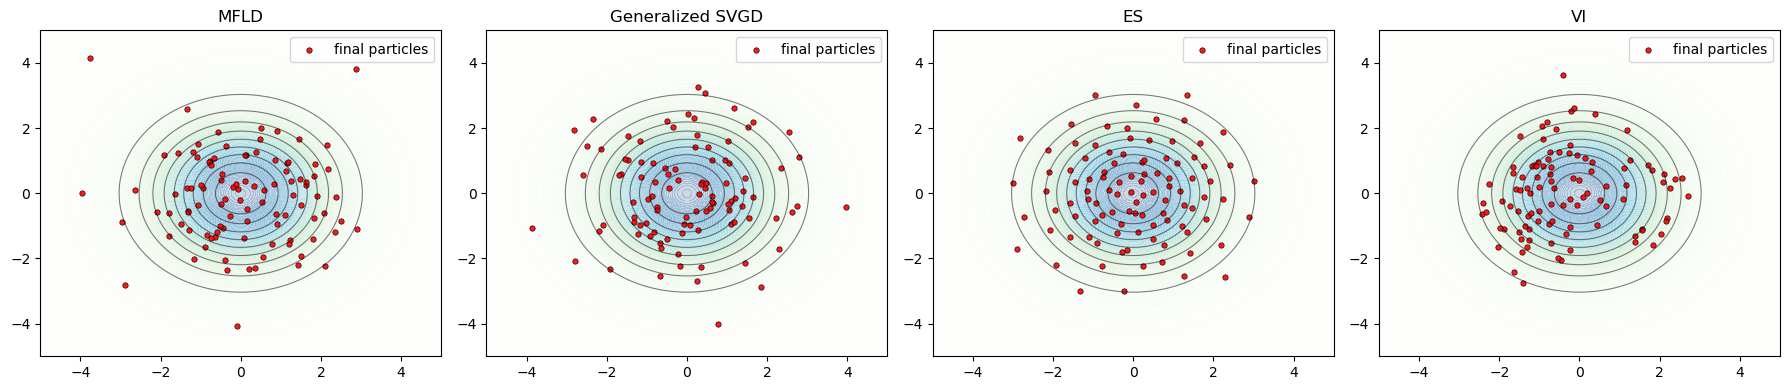

In [19]:
mean = jnp.zeros(2)  
cov = jnp.eye(2) * 2.0  

x = jnp.linspace(-5, 5, 100)
y = jnp.linspace(-5, 5, 100)
X, Y = jnp.meshgrid(x, y)
pos = jnp.dstack((X, Y))

Z = multivariate_normal.pdf(pos, mean, cov)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ind, expe in enumerate(results.keys()):
    
    # Fond dégradé avec transparence
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.2     # transparence du fond
    )
    
    # Lignes de contour par-dessus
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.5
    )
    
    # Points très contrastés
    axes[ind].scatter(
        results_loaded[expe]["X_fin"][:, 0],
        results_loaded[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    axes[ind].set_xlim(-5, 5)
    axes[ind].set_ylim(-5, 5)
    axes[ind].set_title(expe)
    axes[ind].legend()

plt.tight_layout()
plt.show()

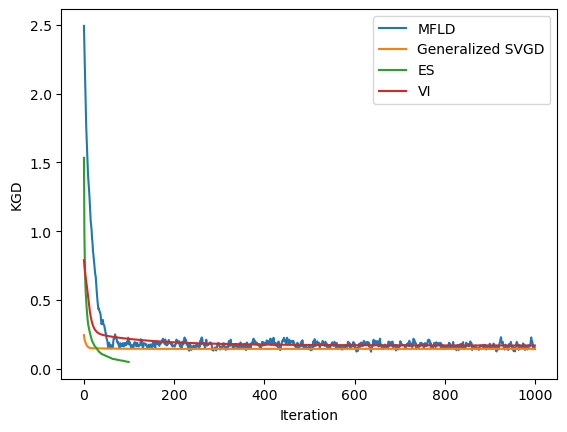

In [20]:
for ind, expe in enumerate(results.keys()):
    plt.plot(results_loaded[expe]["KGD"], label=expe)
plt.xlabel('Iteration')
plt.ylabel('KGD')
plt.legend()

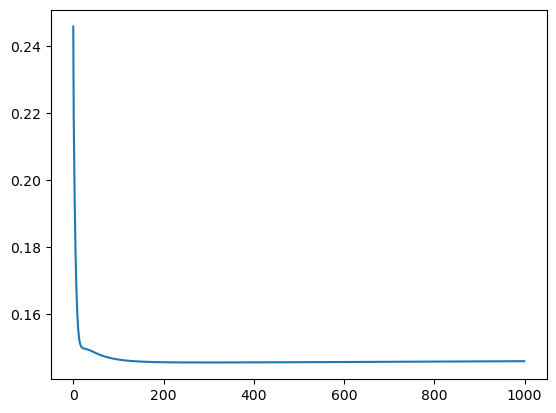

In [99]:
plt.plot(results_loaded["Generalized SVGD"]["KGD"], label=expe)

# 2. Learning of sinus
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import functions as f
import time

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

In [66]:
device_name = "cpu"

In [31]:
results_NN = {
    "MFLD REF":{
        "X_fin" : None
    },
    "MFLD": {
        "X_fin": None,
        "KGD": None
    },
    "Generalized SVGD": {
        "X_fin": None,
        "KGD_values": None
    },
    "ES": {
        "X_fin": None,
        "KGD_values": None
    },
    "VI": {
        "X_fin": None,
        "KGD_values": None
    }
}

In [ ]:
import pickle

# Chargement depuis le fichier
with open("results_nn.pkl", "rb") as g:
    results_NN = pickle.load(g)

In [32]:

def generate_data(key, s, N, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]

    #explanation function
    def f(z):
        return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

    Y_clean = f(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

N = 300
s=1 #input dimension 
key_data = random.PRNGKey(8)
Z,Y = generate_data(key_data,s, N, noise_std=0.1) # put more noise
#plt.plot(Z,Y,".")

In [33]:
kernel_name = "IMQ"
c = jnp.array(1.0)
b = 3.0
def k(x,y):
    return (c**2 + (x-y).dot(x-y))**(-b)
    #return jnp.dot(x,y)

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*4)) #/ jnp.sqrt((2 * jnp.pi)**d)


def esp_forward(X, z):
    E = jnp.mean(jit(vmap(lambda x : model.apply(unravel_fn(x), z)))(X))
    return E
gamma = 100
def L(X):  
    n = len(X)
    Esp_forward = vmap(lambda z: esp_forward(X, z))(Z)  
    return gamma * jnp.mean((Esp_forward - Y) ** 2) 


key = random.PRNGKey(0)
hidden_dim = 1
model = f.MLP(hidden_dims=[1], output_dim=1)

params = model.init(key, jnp.ones((s,)))  
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)  


k = jit(k)
q_0 = jit(q_0)
esp_forward = jit(esp_forward)
L = jit(L)  
 

# MFLD for the contour
Here we run MFLD for a very large number of iterations and particles and a very small stepsize in order to have a good approximation of the target.

In [34]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k)

In [35]:
T = 100000
n = 500
eta = 10e-6

key_init = random.PRNGKey(200)
key = random.PRNGKey(300)
X_list = [model.init(random.fold_in(key_init, i),jnp.ones((s,))) for i in range(n)]
flat_X_list = [ravel_pytree(p)[0] for p in X_list]  
X0 = jnp.stack(flat_X_list)
all_particles = MFLD.run_particles(eta, T, X0,key)
    
X_fin = all_particles[-1]


In [38]:
results_NN["MFLD REF"]["X_fin"] = X_fin

In [39]:
def kde_mfld(x):
    X = results_NN["MFLD REF"]["X_fin"][:,:2]
    n = X.shape[0]
    h = 1.0 / jnp.sqrt(n)

    diff = (X - x) / h
    sq_dist = jnp.sum(diff**2, axis=1)

    norm_const = 1.0 / (n * (2 * jnp.pi)**(X.shape[1] / 2) * h**X.shape[1])

    density = norm_const * jnp.sum(jnp.exp(-0.5 * sq_dist))
    return density

In [40]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(VI.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

Text(0.5, 1.0, '$\\eta = $ 1e-05')

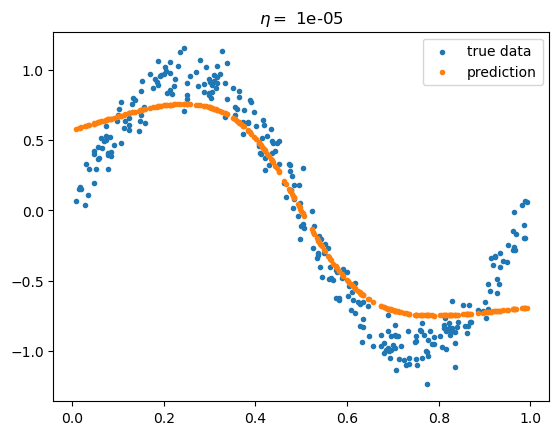

In [41]:
plt.figure()
plt.scatter(Z,Y,label = "true data",marker = ".")
Y_hat = vmap(lambda z : esp_forward(X_fin, z))(Z)
plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
plt.legend()
plt.title(r"$\eta = $ " + str(eta))


# MFLD

In [44]:
T = 10000
n = 200
eta = 1e-6


key_init = random.PRNGKey(200)
key = random.PRNGKey(300)
X_list = [model.init(random.fold_in(key_init, i),jnp.ones((s,))) for i in range(n)]
flat_X_list = [ravel_pytree(p)[0] for p in X_list]  
X0 = jnp.stack(flat_X_list)
all_particles = MFLD.run_particles(eta, T, X0,key)
    
X_fin = all_particles[-1]
results_NN["MFLD"]["X_fin"] = X_fin

# Generalized SVGD

In [43]:
sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm)

T = 10000
n = 200
eta = 0.01 # the best stepsize 

key_init = random.PRNGKey(200)
key = random.PRNGKey(300)
X_list = [model.init(random.fold_in(key_init, i),jnp.ones((s,))) for i in range(n)]
flat_X_list = [ravel_pytree(p)[0] for p in X_list]  
X0 = jnp.stack(flat_X_list)
all_particles = G_SVGD.run_particles(eta, T, X0)
    
X_fin = all_particles[-1]
results_NN["Generalized SVGD"]["X_fin"] = X_fin

Save the results

In [45]:
import pickle

# Sauvegarde dans un fichier binaire
with open("results_nn.pkl", "wb") as g:
    pickle.dump(results_NN, g)

# Comparison of the Expe for the first 2 dimensions

Upoad results

In [46]:
#Upload results
import pickle

# Chargement depuis le fichier
with open("results_nn.pkl", "rb") as f:
    results_NN_loaded = pickle.load(f)

TypeError: 'NoneType' object is not subscriptable

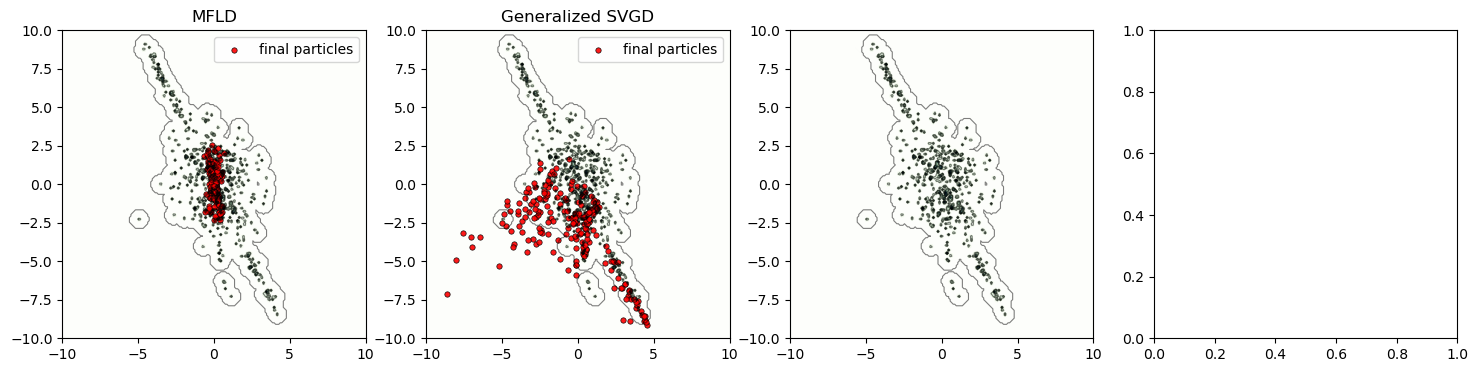

In [47]:
mean = jnp.zeros(2)  
cov = jnp.eye(2) * 2.0  

x = jnp.linspace(-10, 10, 200)
y = jnp.linspace(-10, 10, 200)
X, Y = jnp.meshgrid(x, y)
Z = jnp.array([[kde_mfld(jnp.array([x, y])) for x in x] for y in y])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ind, expe in enumerate(list(results_NN.keys())[1:]):
    
    # Fond dégradé avec transparence
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.2     # transparence du fond
    )
    
    # Lignes de contour par-dessus
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.5
    )
    
    # Points très contrastés
    axes[ind].scatter(
        results_NN_loaded[expe]["X_fin"][:, 0],
        results_NN_loaded[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    # axes[ind].set_xlim(-5, 5)
    # axes[ind].set_ylim(-5, 5)
    axes[ind].set_title(expe)
    axes[ind].legend()

plt.tight_layout()
plt.show()